# Processing

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../raw_data/train.csv')
test_df = pd.read_csv('../raw_data/test.csv')

## Cleaning
Missing Features that need imputation: \
Alley	93.77	str \
LotFrontage	17.74	float64 \
MasVnrType	59.73	str \
MasVnrArea	0.55	float64 \
BsmtQual	2.53	str \
BsmtCond	2.53	str \
BsmtExposure	2.60	str \
BsmtFinType1	2.53	str \
BsmtFinType2	2.60	str \
Electrical	0.07	str \
FireplaceQu	47.26	str \
GarageType	5.55	str \
GarageYrBlt	5.55	float64 \
GarageFinish	5.55	str \
GarageQual	5.55	str \
GarageCond	5.55	str \
PoolQC	99.52	str \
Fence	80.75	str \
MiscFeature	96.30	str \
#### 1.01 Missing imputation: Alley

In [ ]:
# Fill missing values with an integer flag.
df['Alley'] = df['Alley'].notna().astype(int)
test_df['Alley'] = test_df['Alley'].notna().astype(int)

#### 1.02 Missing imputation: LotFrontage

In [4]:
# Check correlational features with LotFrontage to understand plausability of imputation methods.
df.select_dtypes(include=['number']).corr()['LotFrontage'].sort_values(ascending=False)

LotFrontage      1.000000
1stFlrSF         0.457181
LotArea          0.426095
GrLivArea        0.402797
TotalBsmtSF      0.392075
TotRmsAbvGrd     0.352096
SalePrice        0.351799
GarageArea       0.344997
GarageCars       0.285691
Fireplaces       0.266639
BedroomAbvGr     0.263170
OverallQual      0.251646
BsmtFinSF1       0.233633
PoolArea         0.206167
FullBath         0.198769
MasVnrArea       0.193458
OpenPorchSF      0.151972
BsmtUnfSF        0.132644
YearBuilt        0.123349
BsmtFullBath     0.100949
YearRemodAdd     0.088866
WoodDeckSF       0.088521
2ndFlrSF         0.080177
GarageYrBlt      0.070250
3SsnPorch        0.070029
HalfBath         0.053532
BsmtFinSF2       0.049900
ScreenPorch      0.041383
LowQualFinSF     0.038469
MoSold           0.011200
EnclosedPorch    0.010700
YrSold           0.007450
MiscVal          0.003368
KitchenAbvGr    -0.006069
BsmtHalfBath    -0.007234
Id              -0.010601
OverallCond     -0.059213
Alley           -0.173249
MSSubClass  

In [5]:
# .02 Numerical imputation: LotFrontage
# Check overlapping rows between LotFrontage and features for potential imputation
missing_lotfrontage = df['LotFrontage'].isna()
features_for_lotfrontage_imputation = ['1stFlrSF', 'LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']
for feature in features_for_lotfrontage_imputation:
    overlap = missing_lotfrontage & df[feature].isna()
    if not overlap.any():
        print(f'{feature} doesnt contain any missing overlapping rows with LotFrontage ✅')
    else: print(f'{feature} has overlapping rows with LotFrontage')

1stFlrSF doesnt contain any missing overlapping rows with LotFrontage ✅
LotArea doesnt contain any missing overlapping rows with LotFrontage ✅
GrLivArea doesnt contain any missing overlapping rows with LotFrontage ✅
TotalBsmtSF doesnt contain any missing overlapping rows with LotFrontage ✅
GarageArea doesnt contain any missing overlapping rows with LotFrontage ✅


In [6]:
# .02 Numerical imputation: LotFrontage
# Linear regression imputation of LotFrontage using highly correlational features.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[df['LotFrontage'].notna()][features_for_lotfrontage_imputation]
y = df[df['LotFrontage'].notna()]['LotFrontage']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print(f'R^2 score: {r2_score(y_test, model.predict(X_test))}')

R^2 score: 0.3201586136322617


In [7]:
# Poor R2 score from linear regression. 
# Investigating...
# How much does just predicting the mean explain?
y_mean = df[df['LotFrontage'].notna()]['LotFrontage'].mean()
y_actual = df[df['LotFrontage'].notna()]['LotFrontage']
baseline_r2 = 1 - (((y_actual - y_mean) ** 2).sum() / ((y_actual - y_actual.mean()) ** 2).sum())
print(f"Baseline R² (just predicting mean): {baseline_r2}")

Baseline R² (just predicting mean): 0.0


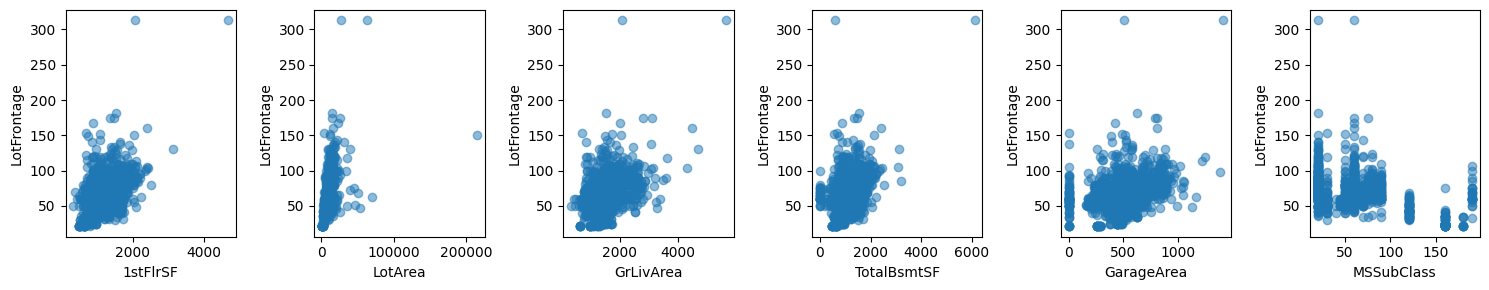

In [8]:
# Check relationships of highly correlational features and the target class. 
import matplotlib.pyplot as plt

features_for_lotfrontage_imputation = ['1stFlrSF', 'LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'MSSubClass']

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, feature in enumerate(features_for_lotfrontage_imputation):
    axes[i].scatter(df[feature], df['LotFrontage'], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('LotFrontage')
plt.tight_layout()
plt.show()

In [9]:
# Due to visualisations clearly showing a non-linear relationship, use RF instead and check outcomes. 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

X = df[df['LotFrontage'].notna()][features_for_lotfrontage_imputation]
y = df[df['LotFrontage'].notna()]['LotFrontage']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter tuning
param_dist = {
    'max_depth': [5,10,15,20,30],
    'n_estimators': [50,100,200,300],
    'min_samples_leaf': [1,2,4,8]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
model = random_search.best_estimator_

print(f"Best params: {random_search.best_params_}")
print(f"R² Score: {r2_score(y_val, model.predict(X_val))}")

Best params: {'n_estimators': 50, 'min_samples_leaf': 1, 'max_depth': 5}
R² Score: 0.5873276922410025


In [10]:
# RF performs well with 0.57 score.. thus, impute on the training and test data.
# Impute on training
missing_mask = df['LotFrontage'].isna()
X_missing = df[missing_mask][features_for_lotfrontage_imputation]
df.loc[missing_mask, 'LotFrontage'] = model.predict(X_missing)

# Imputing on test
test_missing_mask = test_df['LotFrontage'].isna()
X_test_missing = test_df[test_missing_mask][features_for_lotfrontage_imputation]
test_df.loc[test_missing_mask, 'LotFrontage'] = model.predict(X_test_missing)

print(f"LotFrontage missing: {df['LotFrontage'].isna().sum()}")
print(f"test data LotFrontage missing: {test_df['LotFrontage'].isna().sum()}")

LotFrontage missing: 0
test data LotFrontage missing: 0


#### 1.03 Missing imputation: MasVnrType

In [11]:
# In the data_description.txt, a valid input was None, thus, missing values imputed with None.
df['MasVnrType'] = df['MasVnrType'].fillna('None')
test_df['MasVnrType'] = test_df['MasVnrType'].fillna('None')

#### 1.04 Missing imputation: All string columns below 5% missing

In [12]:
# All missing are very low, thus imputed with N/A as some houses don't have a 
# basement or garage
columns_for_NA_imputation = [
    'BsmtQual', 
    'BsmtCond', 
    'BsmtExposure', 
    'BsmtFinType1',
    'BsmtFinType2',
    'Electrical', 
    'GarageType', 
    'GarageFinish', 
    'GarageQual', 
    'GarageCond'
    ]

df[columns_for_NA_imputation] = df[columns_for_NA_imputation].fillna('N/A')
test_df[columns_for_NA_imputation] = test_df[columns_for_NA_imputation].fillna('N/A')

#### 1.05 Missing imputation: MasVnrArea

In [13]:
# Very+ low missing percentage. Will impute with Mean. 
MasVnrArea_training_mean = df['MasVnrArea'].mean()
df['MasVnrArea'] = df['MasVnrArea'].fillna(MasVnrArea_training_mean)
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(MasVnrArea_training_mean)

#### 1.06 Missing imputation: FireplaceQu

In [14]:
# Missing values are supposed to be NA. e.g. No fireplace.
df['FireplaceQu'] = df['FireplaceQu'].fillna('NA')
test_df['FireplaceQu'] = test_df['FireplaceQu'].fillna('NA')

#### 1.05 Missing imputation: GarageYrBlt

In [15]:
# Missing values are supposed to be NA. e.g. No Garage.
df['GarageYrBlt'] = df['GarageYrBlt'].fillna('NA')
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna('NA')

#### 1.06 Missing imputation: PoolQC

In [16]:
# Missing values are supposed to be NA. e.g. No Pool.
df['PoolQC'] = df['PoolQC'].fillna('NA')
test_df['PoolQC'] = test_df['PoolQC'].fillna('NA')

#### 1.07 Missing imputation: Fence

In [17]:
# Missing values are supposed to be NA. e.g. No Fence.
df['Fence'] = df['Fence'].fillna('NA')
test_df['Fence'] = test_df['Fence'].fillna('NA')

#### 1.08 Missing imputation: MiscFeature

In [18]:
# Missing values are supposed to be NA. e.g. No Misc feature.
df['MiscFeature'] = df['MiscFeature'].fillna('NA')
test_df['MiscFeature'] = test_df['MiscFeature'].fillna('NA')

In [19]:
# Final check for null instances
null_info = pd.DataFrame({
    'null_percent': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
})
null_info[null_info['null_percent'] > 0]

,null_percent,dtype


In [20]:
df['Neighborhood']

0       CollgCr
1       Veenker
2       CollgCr
3       Crawfor
4       NoRidge
         ...   
1455    Gilbert
1456     NWAmes
1457    Crawfor
1458      NAmes
1459    Edwards
Name: Neighborhood, Length: 1460, dtype: str

# Post-training feature engineering

Commented out due to reduction in prediction quality

In [21]:
# new_features = pd.DataFrame({
#     # 
#     'HouseAge': df['YrSold'] - df['YearBuilt'],
#     'RemodAge': df['YrSold'] - df['YearRemodAdd'],
#     #
#     'QualityArea' : df['OverallQual'] * df['GrLivArea'],
#     'QualityBsmt' : df['OverallQual'] * df['TotalBsmtSF'],
#     #
#     'TotalArea' : df['GrLivArea'] + df['TotalBsmtSF'],
#     #
#     'NeighborhoodMedianPrice' : df.groupby('Neighborhood')['SalePrice'].transform('median')
# }, index=df.index)

# df = pd.concat([df, new_features], axis = 1)

### Encoding of categorical columns

In [22]:
# Encode categorical cols with get_dummies
df = pd.get_dummies(df, drop_first=True)
test_df = pd.get_dummies(test_df, drop_first=True)
test_df = test_df.reindex(columns=df.columns, fill_value=0)
test_df = test_df.drop('SalePrice', axis=1)

In [23]:
df.shape

(1460, 357)

In [24]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,Alley,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.721737,10516.828082,0.062329,6.099315,5.575342,1971.267808,1984.865753,103.685262,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,23.170439,9981.264932,0.241835,1.382997,1.112799,30.202904,20.645407,180.569112,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,0.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,0.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,70.000000,9478.500000,0.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,81.765496,11601.500000,0.000000,7.000000,6.000000,2000.000000,2004.000000,164.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,1.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [25]:
df.columns = df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Exporting data to processed
df.to_csv('../processed/training_data.csv', index=False)
test_df.to_csv('../processed/test_data.csv', index=False)